# 1. Import Required Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

# 2. Load Saved Dataset

In [2]:
train_dataset = tf.data.Dataset.load("processed_train_dataset")

val_dataset = tf.data.Dataset.load("processed_validation_dataset")

print("Datasets loaded successfully.")

Datasets loaded successfully.


# 3. Class Names

In [3]:
class_names = [
    "Pepper_bell_Bacterial_spot",
    "Pepper_bell_healthy"
]

print(class_names)

['Pepper_bell_Bacterial_spot', 'Pepper_bell_healthy']


# 4. Data Augmentation Layer

In [4]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

])

# 5. Build CNN Model

In [5]:
model = models.Sequential([

    # Data Augmentation
    data_augmentation,

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(128, 128, 3)),

    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.MaxPooling2D((2, 2)),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Dropout Layer
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(2, activation='softmax')

])

model.summary()

C:\Users\sai\tf_working_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 6. Compile Model

In [6]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

print("Model compiled successfully.")

Model compiled successfully.


# 7. Early Stopping

In [7]:
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

# 8. Train Model

In [8]:
EPOCHS = 20

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=[early_stopping]

)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 57s 835ms/step - accuracy: 0.7949 - loss: 2.5373 - val_accuracy: 0.8635 - val_loss: 0.3150
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 606ms/step - accuracy: 0.9042 - loss: 0.3474 - val_accuracy: 0.9430 - val_loss: 0.2584
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 644ms/step - accuracy: 0.9143 - loss: 0.2528 - val_accuracy: 0.7576 - val_loss: 0.5070
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9441 - loss: 0.1675 - val_accuracy: 0.8921 - val_loss: 0.2693
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 56s 901ms/step - accuracy: 0.9415 - loss: 0.1774 - val_accuracy: 0.8534 - val_loss: 0.3644
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 49s 785ms/step - accuracy: 0.9531 - loss: 0.1541 - val_accuracy: 0.9756 - val_loss: 0.0987
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 690ms/step - accuracy: 0.9526 - loss: 0.1520 - val_accuracy: 0.9572 - val_loss: 0.1222
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 49s 793ms/step - accuracy: 0.9592 - loss: 0.1263 - val_accurac

# 9. Evaluate Model

In [9]:
test_loss, test_accuracy = model.evaluate(val_dataset)

print("Validation Loss :", test_loss)

print("Validation Accuracy :", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.9756 - loss: 0.0987
Validation Loss : 0.09866973757743835
Validation Accuracy : 0.9755600690841675


# 10. Plot Accuracy Graph

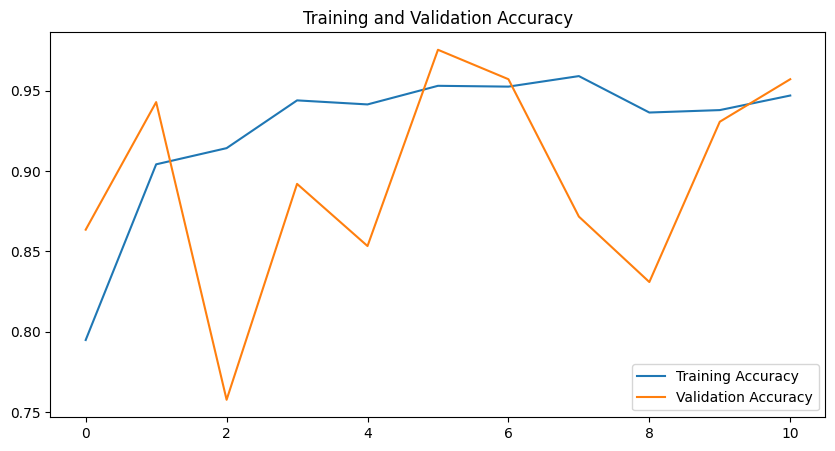

In [10]:
acc = history.history['accuracy']

val_acc = history.history['val_accuracy']

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, acc, label='Training Accuracy')

plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.legend(loc='lower right')

plt.title('Training and Validation Accuracy')

plt.show()

# 11. Plot Loss Graph

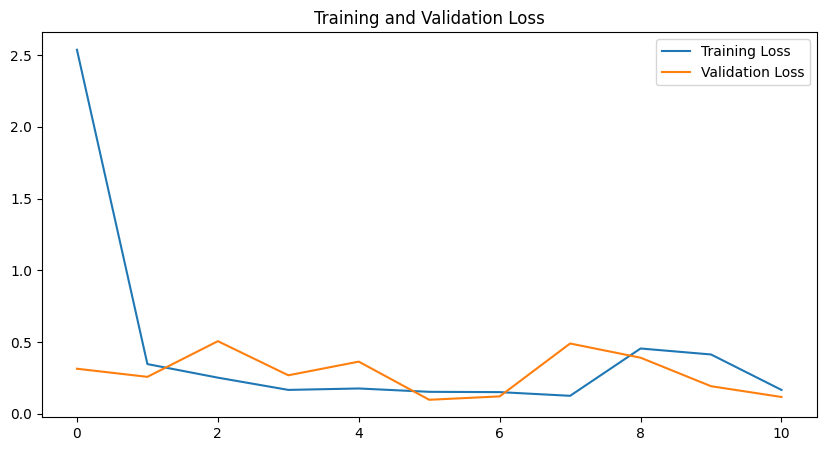

In [11]:
loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(len(loss))

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, loss, label='Training Loss')

plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend(loc='upper right')

plt.title('Training and Validation Loss')

plt.show()

# 12. Save Model

In [12]:
model.save("plant_disease_detection_model.keras")

print("Model saved successfully.")

Model saved successfully.


# 13. Load Model 

In [13]:
# ==========================================
# 13. Load Model (Optional)
# ==========================================

loaded_model = tf.keras.models.load_model(
    "plant_disease_detection_model.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


# 14. Predict on Single Image

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image

image_path = "../PlantVillage/Pepper__bell___healthy/pepper_bell_1.jpg"

img = image.load_img(
    image_path,
    target_size=(128, 128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)

print("Predicted Class :", predicted_class)

print("Confidence :", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
Predicted Class : Pepper_bell_Bacterial_spot
Confidence : 0.6654058


# 15. Display Predicted Image

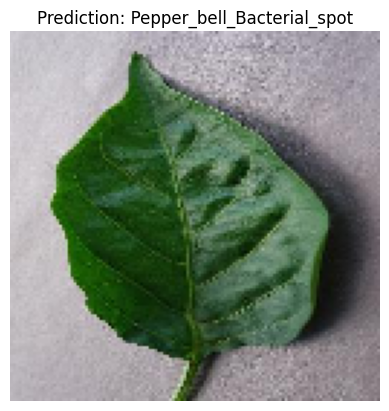

In [20]:
plt.imshow(img)

plt.title(f"Prediction: {predicted_class}")

plt.axis("off")

plt.show()